# Assignment 2 -- ML4F 2023

## Instructions
* This assignment covers the material discussed in Lectures ML1 - ML9. 
* Each group submits _only one_ notebook via canvas on the assignment page. 
* The notebook should be named `assignment1_groupXX.ipynb` where `XX` is your group number,  
e.g. for group 3 this will be `assignment1_group03.ipynb`.
* The notebook should run without raising any errors. 
* We recommend keeping the folder structure
```
assignment/
    data/
    lib/
    assignment1_groupXX.ipynb
```
* We strongly recommend git, as you are encouraged to collaborate and split up the work and maybe even start independently. To see how to set up your own repo for your group, see `VU Workshop Introduction to Version Control with GIT.pptx` discussed in week 2.
* Do not spend time on optimizing the speed of your code. However, if it runs for more than 5 minutes, we will terminate it.
* We strongly encourage you to experiment, try different approaches and combinations and get to know the problem from alternative angles. But the final notebook should only contain the necessary results for grading.
----

<div style="font-size:24px; text-align:center; font-weight:bold">Good luck!</div>

----

# Assignment 2 - Neural Nets & Explainability

The hedge fund managers of G. Mane Investments are looking into trading in Call options on small cap stocks. You are assigned a stock on Canvas, and the option data on this stock is achieved using the function given below. Do not alter anything about the function, as it creates a nice dataset containing the following features:

* Forward Price
* Strike
* Implied Volatility
* Maturity
* Volume
* Open Interest
* Bid
* Ask
* Price

Make sure to download the dataset as CSV right away, so it doesn't change throughout the week, when the markets trade.

Since there is only a limited amount of option data available, the fund managers would like you to use comparable stocks to train a ML model on, so they can use it to price their options accurately. 

State your imports below.

In [1]:
import yfinance as yf
import datetime as datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter("ignore", UserWarning)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import ElasticNet
from scipy.stats import boxcox
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import shap

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def getOptionData(s):
    """
    Purpose:
        Get stock/index option data into a usable format
        
    Input:
        s    string, asset ticker
       
    Output:
       df    Dataframe, option data
    """
    ticker = yf.Ticker(s)
    exps = ticker.options
    expirations = [datetime.datetime.strptime(i, '%Y-%m-%d') for i in exps]  
    s0 = ticker.history(period="1d")['Close'].iloc[0]
    vT = []
    vF = []
    c = 0
    for i in expirations:
        diff = i - datetime.datetime.now()
        if diff.total_seconds() > 0:
            ttm = diff.total_seconds() / 31536000
            vT.append(ttm) # Set TTM to yearly
            f0 = s0 * np.exp(ttm) # Get Forward Price
            vF.append(f0)
        else:
            c += 1
    vK = [] # ATM Strike
    vIV = [] # ATM IV
    vC = [] # ATM Call Price 
    vnF = []
    vnT = []
    vV = []
    vO = []
    vA = []
    vB = []
    for i in range(c, len(exps)):
        options = ticker.option_chain(exps[i])
        for index, row in options.calls.iterrows():
            vnF.append(vF[i - c])
            vK.append(row['strike'])
            vIV.append(row['impliedVolatility'])
            vC.append(row['lastPrice'])
            vnT.append(vT[i - c])
            vV.append(row['volume'])
            vO.append(row['openInterest'])
            vA.append(row['ask'])
            vB.append(row['bid'])
    df = pd.DataFrame([vnF, vK, vIV, vnT, vV, vO, vB, vA, vC]).transpose()
    df = df.set_axis(['Forward', 'Strike', 'Implied Volatility', 'Maturity', 'Volume', 'Open Interest', 'Bid', 'Ask', 'Call'], axis=1)
    return df

In [2]:
#df_test = getOptionData('BZH')
df_test = pd.read_csv('BZH.csv')

In [3]:
df_test.head()

,Forward,Strike,Implied Volatility,Maturity,Volume,Open Interest,Bid,Ask,Call
0,26.945554,3.0,0.000010,0.042669,22.0,22.0,10.6,11.6,9.80
1,26.945554,5.0,0.000010,0.042669,1.0,3.0,17.0,17.8,16.50
2,26.945554,8.0,0.000010,0.042669,NaN,1.0,5.6,6.1,6.38
3,26.945554,10.0,0.000010,0.042669,4.0,0.0,0.0,0.0,17.33
4,26.945554,11.0,7.064454,0.042669,NaN,4.0,18.5,19.1,22.04


In [4]:
#df_test.to_csv(r'C:\Users\Petko\Desktop\Uni\Machine_Learning\Case_1\Finance\BZH.csv', index=False)

# Preprocessing (20 points)
*5 points for correct code*

*15 points for appropriate judgment of preprocessing measures*

---
The provided option data may contain some issues that need to be dealt with by preprocessing the data. Take a good look at the data and check for NaN's, outliers or other issues. 

Some options aren't being traded at all, because of a variety of reasons. See to it that these observations are dealt with appropriately.

In [5]:
# Check normality of data
#If not normal, can be log transformed, normal can be standerdized and others can be normalised if we deal with outliers.

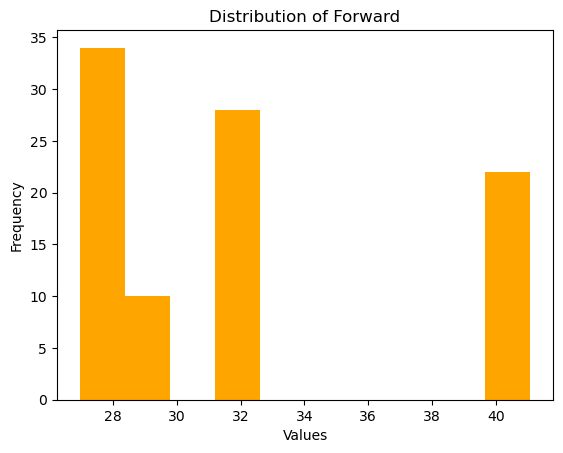

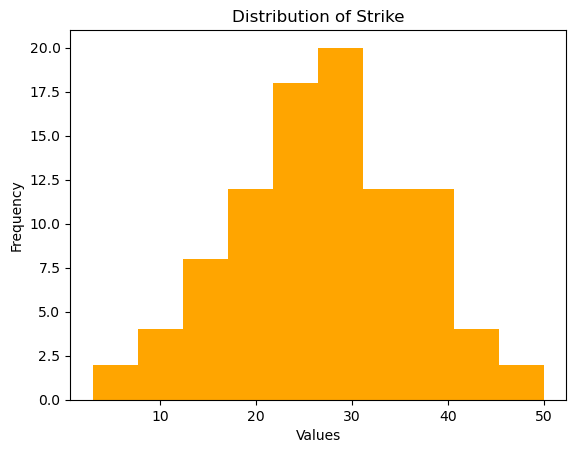

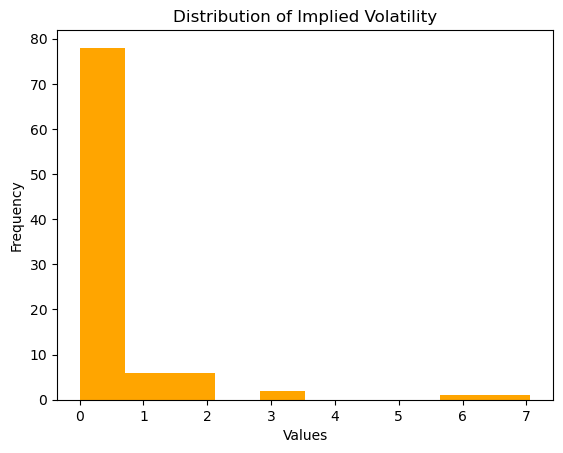

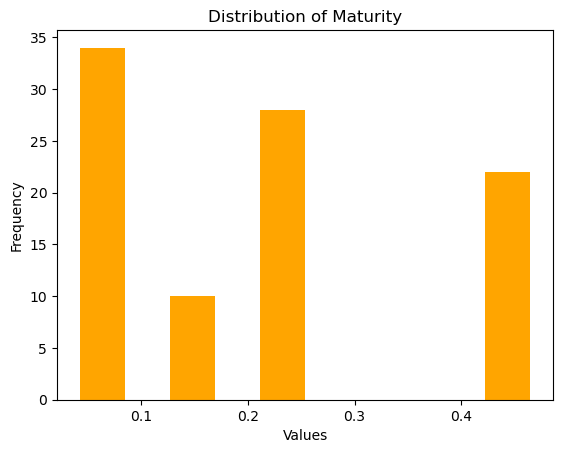

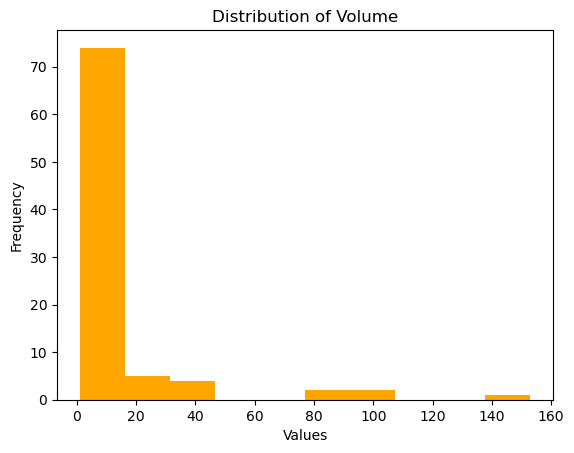

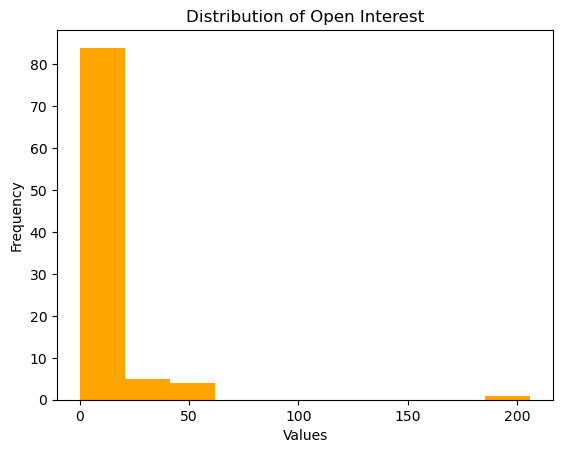

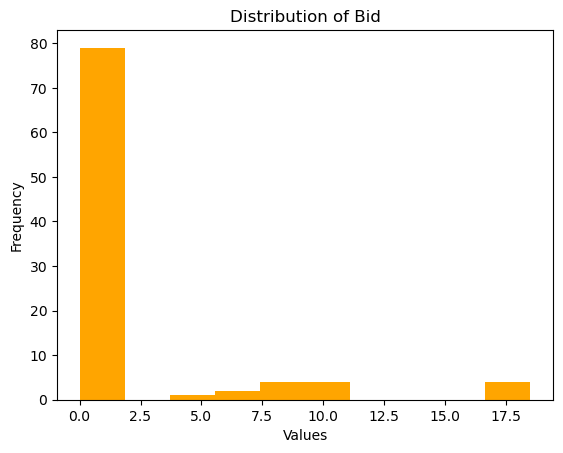

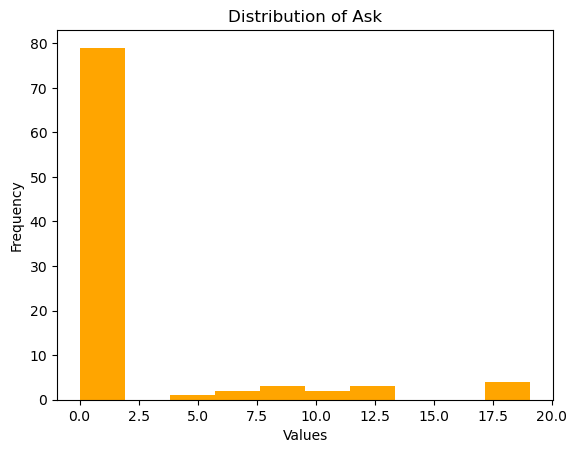

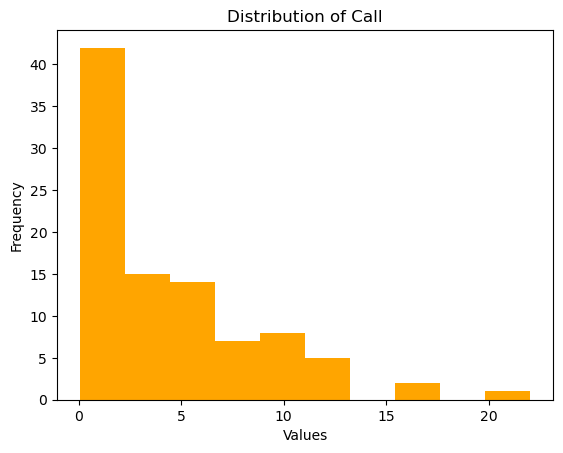

In [6]:
for i in df_test.columns:
    plt.hist(df_test[i], bins = 10, color= 'orange')
    plt.xlabel('Values')
    plt.ylabel('Frequency')
    plt.title('Distribution of ' + str(i))
    plt.show()

In [7]:
transformed_bid = boxcox(df_test['Ask'] + 0.1)

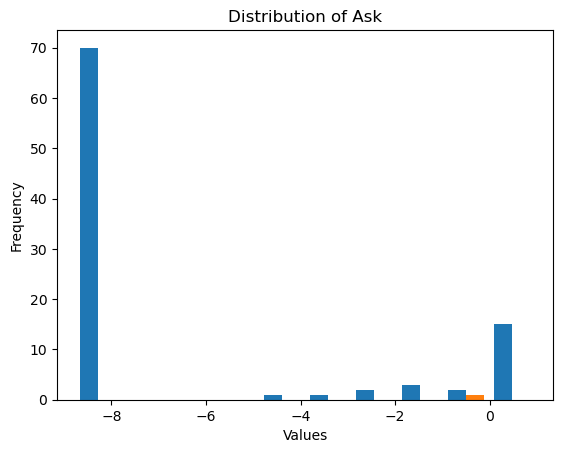

In [8]:
plt.hist(transformed_bid, bins = 10)
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Distribution of Ask')
plt.show()

In [9]:
scaler = MinMaxScaler()
asd = scaler.fit_transform(df_test[['Ask']])

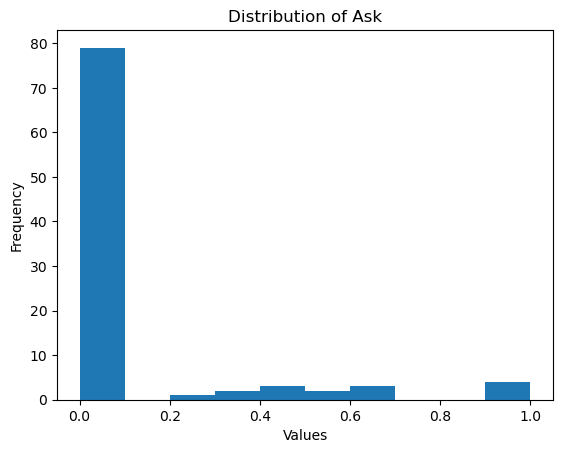

In [10]:
plt.hist(asd, bins = 10)
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Distribution of Ask')
plt.show()

In [11]:
df_test['Bid']

0     10.60
1     17.00
2      5.60
3      0.00
4     18.50
      ...  
89     0.00
90     0.00
91     0.00
92     0.55
93     0.00
Name: Bid, Length: 94, dtype: float64

In [12]:
df_test['Volume'] = df_test['Volume'].fillna(0) # Replace all NaN with zeros.

In [13]:
(df_test['Ask']==0).sum()

70

In [14]:
df_test['Ask'].count

<bound method Series.count of 0     11.6
1     17.8
2      6.1
3      0.0
4     19.1
      ... 
89     0.0
90     0.0
91     0.0
92     0.7
93     0.0
Name: Ask, Length: 94, dtype: float64>

# Training (40 points)
*10 points for correct code*

*10 points for selection judgement*

*10 points for hyperparameter optimization*

*10 points for resulting metrics*

---
In order to put together a set of training data, a selection of other stocks is provided by the analysts of G. Mane Investments:


You can use all of the stocks or just a selection to include in your training set, or all of them. Comment on the consideration between a bigger dataset and in/excluding a bias in your dataset.

Now that your training set is completed, you can train a Multi-Layered Perceptron Regressor (MLP) on it. Once it is trained, test it on your original dataset. First train it using the default hyperparameters, and then use _GridSearchCV_ to find the optimal hyperparameters. Observe the differences between the default and optimal hyperparameters and comment on it.

Instead of a classification problem, we are now facing a regression problem. Therefore, we observe the Mean Absolute Error (MAE) and the Root Mean Squared Error (RMSE) rather than the Confusion Matrix. Observe both metrics for both the default model as well as for the optimal hyperparameter model, and comment on the results. 

Suppose that you were to split the dataset of the original option data into a train and test set, and use these to train and test an MLP on. Would the metrics from that test be comparable with the previously calculated metrics? If yes, what would they explain? If no, why not?


In [15]:
selection = ['TMHC', 'KBH', 'MHO', 'TPH', 'MTH']
df_train = pd.DataFrame()

### For loop that gets data for all our selected stocks and puts them into one dataframe:

In [16]:
for i in selection:
    df_select = getOptionData(i)
    df_train = pd.concat([df_train, df_select], axis = 0)
    

In [17]:
df_train.tail()
df_train = df_train.fillna(0)

### Do the same preprocessing techniques to this data as we did to our original set:

#### Results using default parameters:

In [18]:
Y = df_train.pop('Call')
Y_test = df_test.pop('Call')

In [19]:
model = MLPRegressor()
model = model.fit(df_train, Y)
Y_pred = model.predict(df_test)

In [20]:
model.score(df_test, Y_test)

0.004551337625711804

In [22]:
print(mean_absolute_error(Y_test, Y_pred))
print(np.sqrt(mean_squared_error(Y_test, Y_pred)))

2.6684004558326566
4.408976533418623


#### Results with optimised parameters:

In [ ]:
#model_grid = MLPRegressor()
#params = {'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'solver': ['adam', 'lbfgs'],
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [100, 200],
    'early_stopping': [True, False],
    'batch_size': [32, 64],
    'verbose': [True]}
#grid = GridSearchCV(model_grid, params)
#grid.fit(df_train, Y)
#Y_pred_grid = grid.predict(df_test)
#print(grid.best_params_)

In [ ]:
print("Best score: ", grid.best_score_)

In [ ]:
print(mean_absolute_error(Y_test, Y_pred_grid))
print(mean_squared_error(Y_test, Y_pred_grid))

### Splitting original dataset and using that for training and testing:

# Recommendation (30 points)
*10 points for SHAP observation*

*10 points for explainability AI*

*10 points for recommendation*

---
Now that you've made an assessment of the transferability of option data, it is time to assess the SHAP values for each included feature. Observe the importance values and comment on the outliers.

Write a recommendation to the managers of G. Mane Investments. Explain what you have researched and present your results in a short paper in no more than 400 words. Focus on the fund's wants and needs, but don't hold back too much on the technical talk. The fund managers would like to discuss your paper with their analysts, who know more than basic maths, but aren't as up-to-date as you on AI. Make sure to cover the different levels of explainability, and the associated concerns.

We recommend writing in LaTeX/Overleaf, but Word or another application is also fine. Hand the paper in as PDF, together with your Jupyter Notebook, in a ZIP-file.

In [23]:
explainer = shap.KernelExplainer(model.predict,df_train)
shap_values = explainer.shap_values(df_test,nsamples=100)

Using 358 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/94 [00:00<?, ?it/s]

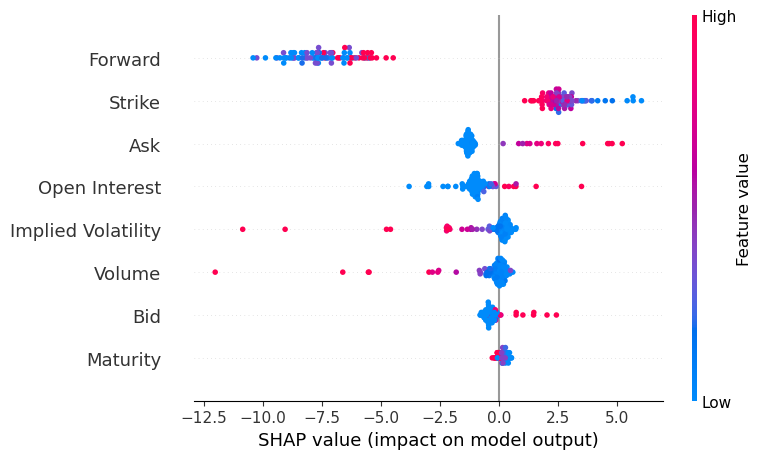

In [24]:
shap.summary_plot(shap_values,df_test,feature_names=df_test.columns)